In [6]:
from skimage.morphology import erosion, dilation, opening, closing
from skimage.morphology import disk
from skimage import color, io
import cv2
from matplotlib import pyplot as plt
import numpy as np
from skimage.filters import threshold_otsu


In [1]:
path = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/imageAnalysisGithub/exercises/ex4b-ImageMorphology/data/"


In [5]:
# Lx-4b.1 Define a structuring element using the disk function from the skimage.morphology module. Use a radius of 5 pixels.
structuring_element = disk(3)
print("Structuring element shape:", structuring_element.shape)
print("Structuring element data type:", structuring_element.dtype)
print("Structuring element:\n", structuring_element)

Structuring element shape: (7, 7)
Structuring element data type: uint8
Structuring element:
 [[0 0 0 1 0 0 0]
 [0 1 1 1 1 1 0]
 [0 1 1 1 1 1 0]
 [1 1 1 1 1 1 1]
 [0 1 1 1 1 1 0]
 [0 1 1 1 1 1 0]
 [0 0 0 1 0 0 0]]


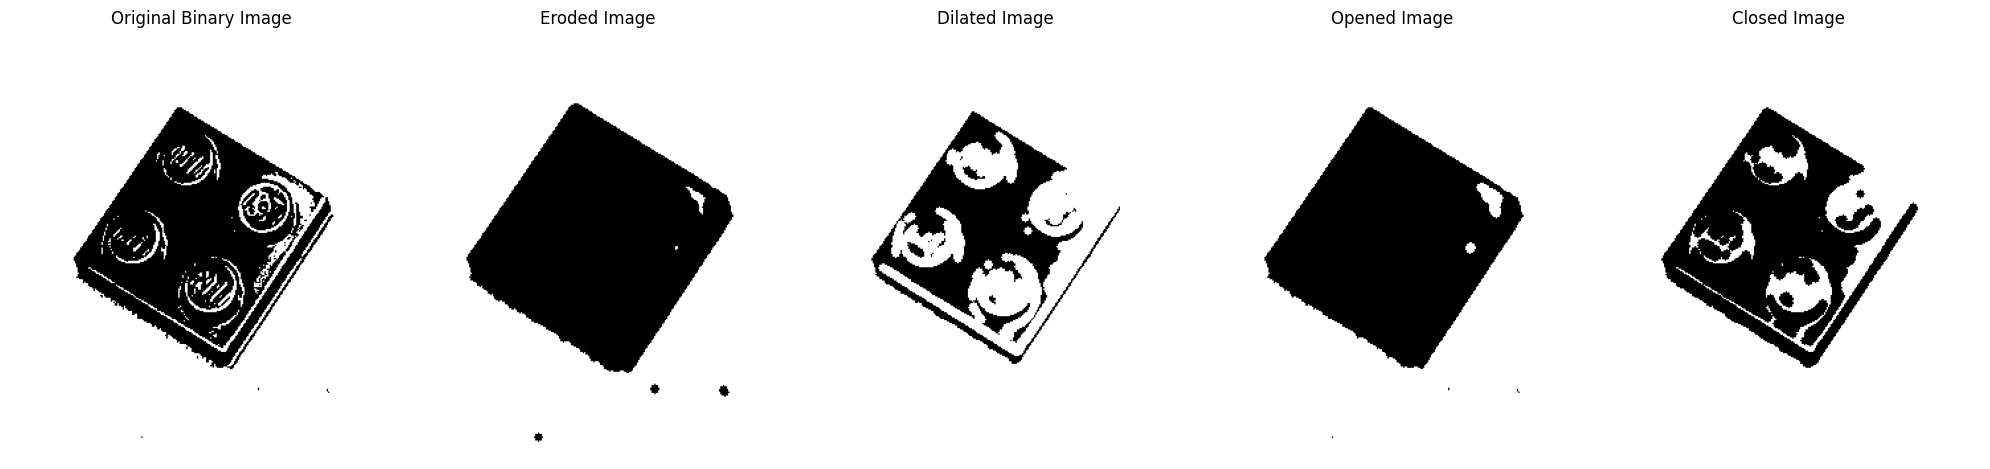

In [7]:
# Lx-4b.2 Apply erosion, dilation, opening and closing on binary image


img_name = "lego_5.png"
img = io.imread(path + img_name)
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
otsu_threshold = threshold_otsu(img_gray)
bin_img = img_gray > otsu_threshold



eroded_img = erosion(bin_img, structuring_element)
dilated_img = dilation(bin_img, structuring_element)
opened_img = opening(bin_img, structuring_element)
closed_img = closing(bin_img, structuring_element)
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
axes[0].imshow(bin_img, cmap='gray')
axes[0].set_title('Original Binary Image')
axes[0].axis('off')
axes[1].imshow(eroded_img, cmap='gray')
axes[1].set_title('Eroded Image')
axes[1].axis('off')
axes[2].imshow(dilated_img, cmap='gray')
axes[2].set_title('Dilated Image')
axes[2].axis('off')
axes[3].imshow(opened_img, cmap='gray')
axes[3].set_title('Opened Image')
axes[3].axis('off')
axes[4].imshow(closed_img, cmap='gray')
axes[4].set_title('Closed Image')
axes[4].axis('off')
plt.tight_layout()
plt.show()



In [8]:
# Lx-4b-3 Compute outlines in bin image
def compute_outline(bin_img):
    """
    Computes the outline of a binary image
    """
    
    footprint = disk(1)
        
    dilated = dilation(bin_img, footprint)
        
    outline = np.logical_xor(dilated, bin_img)
        
    return outline


# From https://scikit-image.org/docs/stable/auto_examples/applications/plot_morphology.html
def plot_comparison(original, filtered, filter_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True,
                                   sharey=True)
    ax1.imshow(original, cmap=plt.cm.gray)
    ax1.set_title('original')
    ax1.axis('off')
    ax2.imshow(filtered, cmap=plt.cm.gray)
    ax2.set_title(filter_name)
    ax2.axis('off')
    io.show()

/tmp/ipykernel_216205/752343006.py:26: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


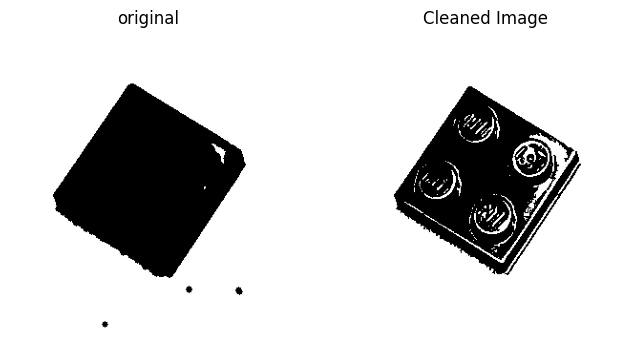

In [9]:
# Lx-4b-4 Remove holes in binary image
from skimage.morphology import remove_small_holes
cleaned_img = remove_small_holes(bin_img, area_threshold=64)

eroded_img = erosion(bin_img, structuring_element)


plot_comparison(eroded_img, cleaned_img, "Cleaned Image")